In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 60)
sns.set_style("whitegrid")
print('Ready.')

Ready.


In [40]:
# Loading property dataset
df = pd.read_csv('data/raw/kaggle_london_house_price_data.csv')
# column rename
df = df.rename(columns={
'rentEstimate_lowerPrice' : 'rent_low',
'rentEstimate_currentPrice' : 'rent',
'rentEstimate_upperPrice' : 'rent_high',
'saleEstimate_lowerPrice' : 'sale_low',
'saleEstimate_currentPrice' : 'sale_price',
'saleEstimate_upperPrice' : 'sale_high',
'saleEstimate_confidenceLevel' : 'confidence',
'saleEstimate_ingestedAt' : 'estimate_date',
'saleEstimate_valueChange.numericChange' : 'sale_change_gbp',
'saleEstimate_valueChange.percentageChange' : 'sale_change_pct',
'saleEstimate_valueChange.saleDate' : 'last_sale_date',
'history_date' : 'hist_date',
'history_price' : 'hist_price',
'history_percentageChange' : 'hist_pct',
'history_numericChange' : 'hist_change_gbp',
})

# Generated outcode to borough lookup table
lookup = pd.read_csv('data/raw/outcode_to_borough.csv')
#  wage data
wages = pd.read_csv('data/raw/london_wages.csv')
# Confirm all three loaded correctly
print(f'Properties: {df.shape[0]:,} rows')
print(f'Lookup table: {lookup.shape[0]} outcodes mapped to boroughs')
print(f'Wage data: {wages.shape[0]} boroughs')

Properties: 418,201 rows
Lookup table: 116 outcodes mapped to boroughs
Wage data: 33 boroughs


In [41]:
# Merge property data with lookup table on the 'outcode' column
# how='left' means: keep ALL property rows, add borough where outcode matches
df_with_borough = df.merge(lookup, on='outcode', how='left')
# Check the result
print(f'Rows before merge: {len(df):,}')
print(f'Rows after merge: {len(df_with_borough):,}')
# These numbers should be IDENTICAL — a left merge never removes rows
# How many properties now have a borough assigned?
has_borough = df_with_borough['borough'].notna().sum()
no_borough = df_with_borough['borough'].isna().sum()
print(f'Properties with borough: {has_borough:,} ({has_borough/len(df)*100:.1f}%)')
print(f'Properties without borough (outcode not in lookup): {no_borough:,}')
# See which outcodes have no borough match — these are gaps in your lookup table
unmatched = df_with_borough[df_with_borough['borough'].isna()]
unmatched_outcodes = unmatched['outcode'].value_counts().head(20)
print('\nTop 20 outcodes with no borough match:')
print(unmatched_outcodes)
# Add these to your lookup CSV to improve coverage

Rows before merge: 418,201
Rows after merge: 418,201
Properties with borough: 379,694 (90.8%)
Properties without borough (outcode not in lookup): 38,507

Top 20 outcodes with no borough match:
outcode
NW2     2089
W1J     1992
W5      1637
N21     1571
W3      1522
N9      1506
NW4     1469
W13     1436
N3      1370
W7      1315
EC2Y    1227
N18     1203
EC1R    1103
EC1Y    1054
EC1V    1053
EC1M     995
SW1E     925
WC1N     925
SW1Y     918
W1F      911
Name: count, dtype: int64


In [42]:
# Merge properties+borough with wages on the 'borough' column
df_full = df_with_borough.merge(wages, on='borough', how='left')
# Confirm the result
print(f'Rows after wage merge: {len(df_full):,}')
# Should still match the original row count — left merge keeps all rows
# Check the new columns are present
print('\nNew columns added:')
print([c for c in df_full.columns if c not in df.columns])
# Preview a few rows to confirm everything looks right
preview_cols = ['fullAddress','outcode','borough',
'rent','sale_price','median_annual_pay']
print(df_full[preview_cols].dropna().head(8).to_string(index=False))

Rows after wage merge: 418,201

New columns added:
['borough', 'median_annual_pay']
                                            fullAddress outcode        borough    rent  sale_price  median_annual_pay
Flat 35, Octavia House, Medway Street, London, SW1P 2TA    SW1P    Westminster  2950.0    759000.0            63500.0
        24 Chester Court, Lomond Grove, London, SE5 7HS     SE5      Southwark  2000.0    388000.0            46300.0
                  18 Alexandra Gardens, London, N10 3RL     N10       Haringey  4850.0   1261000.0            38700.0
                     17 Collins Street, London, SE3 0UG     SE3      Greenwich  3500.0    944000.0            35800.0
                     14 Theodore Road, London, SE13 6HT    SE13       Lewisham  2800.0    726000.0            37500.0
                    6 Victoria Square, London, SW1W 0QY    SW1W    Westminster 23200.0   6024000.0            63500.0
              61 Chestnut Avenue South, London, E17 9EJ     E17 Waltham Forest  3700.0    

In [43]:
# Only work with rows that have rent, wage, AND sale price
afford = df_full.dropna(subset=['rent','median_annual_pay','sale_price']).copy()
print(f'Rows available for affordability analysis: {len(afford):,}')
# ■■ MEASURE 1: Monthly rent as percentage of monthly wage ■■■■
afford['monthly_wage'] = afford['median_annual_pay'] / 12
afford['rent_to_income_pct']= (afford['rent'] /
afford['monthly_wage'] * 100).round(1)
# ■■ MEASURE 2: Months of salary needed to buy the property ■■
afford['months_to_buy']= (afford['sale_price'] /
afford['monthly_wage']).round(1)
# ■■ MEASURE 3: Years of salary needed to buy ■■■■■■■■■■■■■■■■■
afford['years_to_buy'] = (afford['months_to_buy'] / 12).round(1)
# Sanity check — do these numbers make sense for London?
print('\nAffordability summary:')
print(f'Median rent-to-income: {afford["rent_to_income_pct"].median():.1f}%')
print(f'Median months to buy: {afford["months_to_buy"].median():.0f} months')
print(f'Median years to buy: {afford["years_to_buy"].median():.1f} years')
print(f'\n% of properties above 30% rent-to-income (stressed):')
stressed = (afford['rent_to_income_pct'] > 30).mean() * 100
print(f' {stressed:.1f}% of properties')

Rows available for affordability analysis: 378,247

Affordability summary:
Median rent-to-income: 73.1%
Median months to buy: 172 months
Median years to buy: 14.3 years

% of properties above 30% rent-to-income (stressed):
 98.8% of properties


In [44]:
# A rent-to-income ratio above 30% is considered financially stressful by housing experts. My dataset shows 73.1% of London properties exceed this threshold.
# The median London worker needs 14.3 years of salary to purchase the median London property. For context, the UK national average is approximately 9 years.


In [45]:
# Group by borough and calculate median affordability measures(rent to income)
borough_afford = (afford
.groupby('borough')
.agg(
median_rent = ('rent', 'median'),
median_sale_price = ('sale_price', 'median'),
median_wage = ('median_annual_pay','median'),
rent_to_income = ('rent_to_income_pct','median'),
years_to_buy = ('years_to_buy', 'median'),
property_count = ('rent', 'count'),
)
.reset_index()
.sort_values('rent_to_income', ascending=False)
.reset_index(drop=True)
)
# Only include boroughs with at least 50 properties — small samples mislead
borough_afford = borough_afford[borough_afford['property_count'] >= 50]
# Add an affordability rank
borough_afford['rank'] = range(1, len(borough_afford) + 1)
# Print the full ranking table — this is your main result
print('LONDON BOROUGH AFFORDABILITY RANKING')
print('(1 = least affordable, higher rank = more affordable)')
print('-' * 70)
for _, row in borough_afford.iterrows():
    print(f"{row['rank']:2}. {row['borough']:<30} ",
    f"Rent: £{row['median_rent']:.0f}/mo ",
    f"Ratio: {row['rent_to_income']:.1f}% ",
    f"Buy: {row['years_to_buy']:.1f}yrs")

LONDON BOROUGH AFFORDABILITY RANKING
(1 = least affordable, higher rank = more affordable)
----------------------------------------------------------------------
 1. Hounslow                        Rent: £3050/mo  Ratio: 98.4%  Buy: 21.7yrs
 2. Richmond upon Thames            Rent: £3900/mo  Ratio: 91.4%  Buy: 22.7yrs
 3. Westminster                     Rent: £4450/mo  Ratio: 84.1%  Buy: 18.0yrs
 4. Haringey                        Rent: £2650/mo  Ratio: 82.2%  Buy: 16.2yrs
 5. Hackney                         Rent: £2800/mo  Ratio: 81.6%  Buy: 15.7yrs
 6. Brent                           Rent: £2500/mo  Ratio: 81.5%  Buy: 17.5yrs
 7. Camden                          Rent: £3500/mo  Ratio: 80.2%  Buy: 15.7yrs
 8. Bexley                          Rent: £2200/mo  Ratio: 77.4%  Buy: 12.9yrs
 9. Waltham Forest                  Rent: £2300/mo  Ratio: 76.5%  Buy: 15.4yrs
10. Enfield                         Rent: £2200/mo  Ratio: 76.3%  Buy: 16.7yrs
11. Kensington and Chelsea          Rent: £4550/

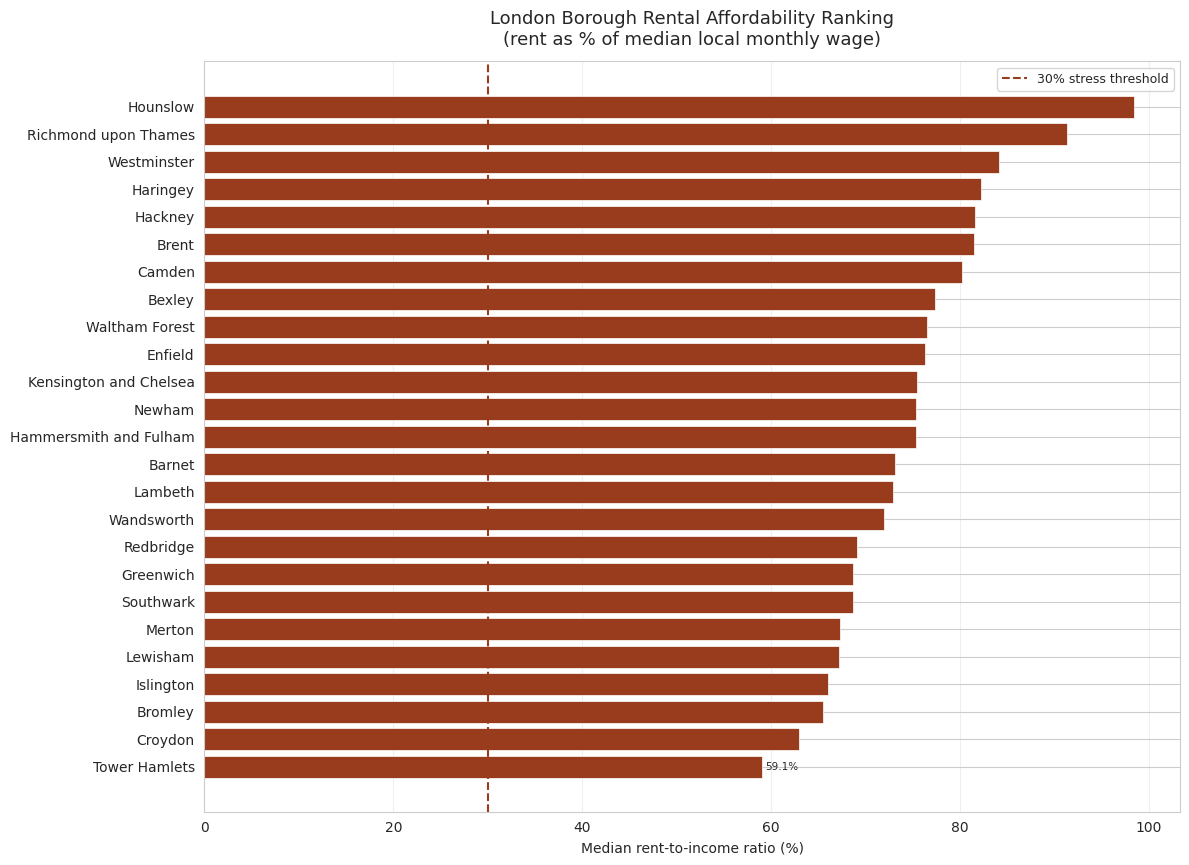

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

This chart is the centrepiece of your portfolio project.


In [48]:
# Borough affordability
# Horizontal bar chart — sorted worst to best
fig, ax = plt.subplots(figsize=(12, max(8, len(borough_afford) * 0.35)))
# Colour bars by severity — red for high stress, green for affordable
colours = ['#993C1D' if r > 40 else
'#BA7517' if r > 30 else
'#0F6E56'
for r in borough_afford['rent_to_income']]
bars = ax.barh(
borough_afford['borough'][::-1],
borough_afford['rent_to_income'][::-1],
color=colours[::-1],
edgecolor='white', linewidth=0.5
)
# Add the 30% stress line — housing experts' threshold
ax.axvline(30, color='#993C1D', linewidth=1.5,
linestyle='--', label='30% stress threshold')
# Add percentage labels on each bar
for bar, val in zip(bars, borough_afford['rent_to_income'][::-1]):
    ax.text(bar.get_width() + 0.3,
    bar.get_y() + bar.get_height()/2,
    f'{val:.1f}%', va='center', fontsize=7.5)
    ax.set_title('London Borough Rental Affordability Ranking\n'
    '(rent as % of median local monthly wage)',
    fontsize=13, pad=12)
    ax.set_xlabel('Median rent-to-income ratio (%)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/13_borough_affordability_ranking.png',
    dpi=150, bbox_inches='tight')
    plt.show()
print('This chart is the centrepiece of your portfolio project.')

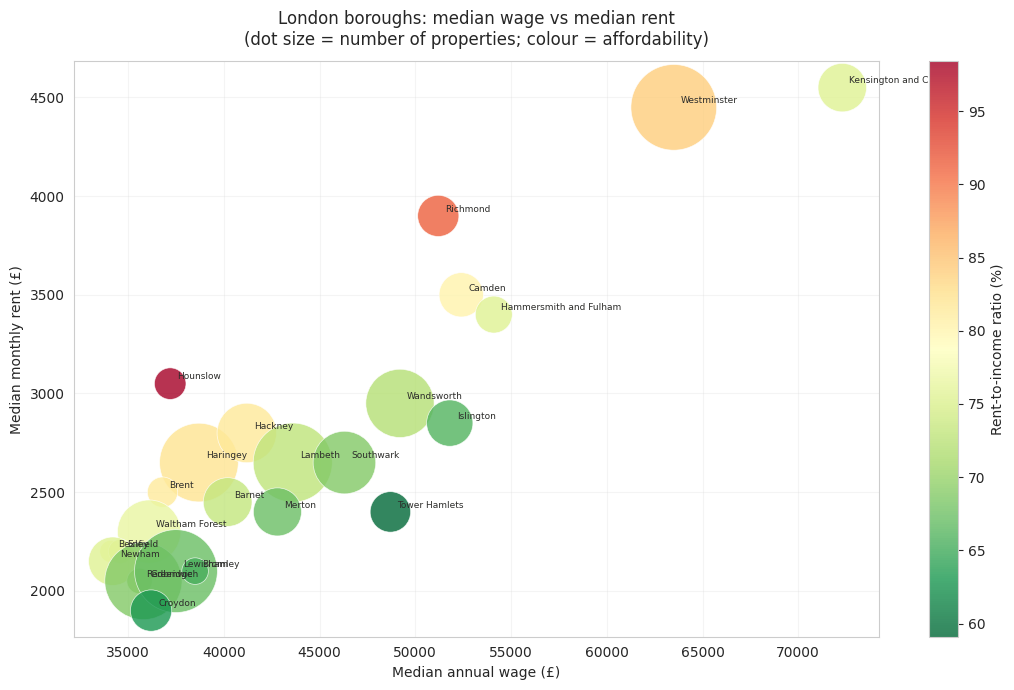

In [49]:
# rent vs wage scatter plot
# Each dot is a borough. X = median wage, Y = median rent
# Dots top-left = high rent, low wage = worst affordability
# Dots bottom-right = low rent, high wage = best affordability
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
borough_afford['median_wage'],
borough_afford['median_rent'],
c=borough_afford['rent_to_income'],
cmap='RdYlGn_r',
# RdYlGn_r = red (bad) to green (good), reversed so red = high ratio
s=borough_afford['property_count'] / 10,
# Size of dot = how many properties in that borough
alpha=0.8, edgecolors='white', linewidths=0.5
)
# Label each dot with the borough name
for _, row in borough_afford.iterrows():
    ax.annotate(
row['borough'].replace(' upon Thames','').replace('upon ',''),
# Shorten long names for readability
(row['median_wage'], row['median_rent']),
textcoords='offset points', xytext=(5, 3),
fontsize=6.5, color='#2C2C2A'
)
plt.colorbar(scatter, ax=ax, label='Rent-to-income ratio (%)')
ax.set_title('London boroughs: median wage vs median rent\n'
'(dot size = number of properties; colour = affordability)',
fontsize=12, pad=12)
ax.set_xlabel('Median annual wage (£)', fontsize=10)
ax.set_ylabel('Median monthly rent (£)', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('outputs/14_wage_vs_rent_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

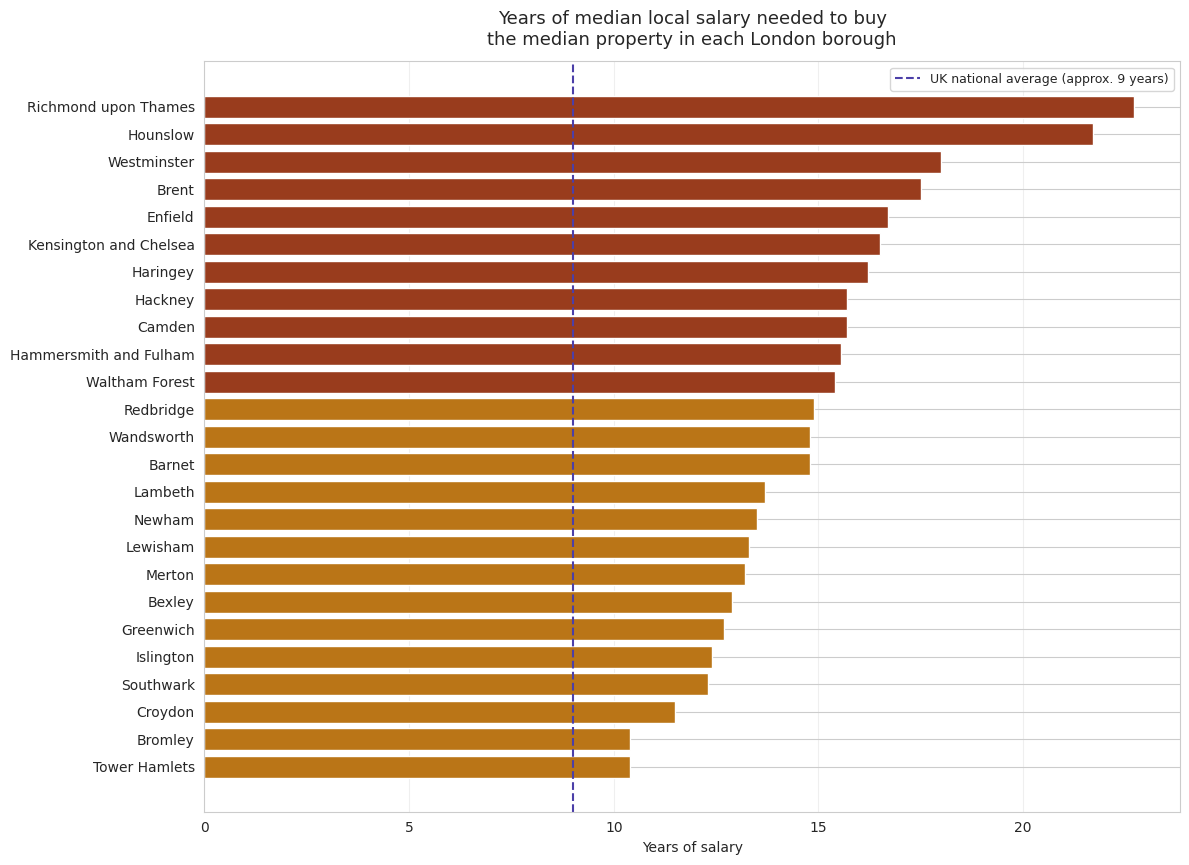

In [50]:

# How many years of salary does a typical worker need to buy in each borough?
buy_df = borough_afford.sort_values('years_to_buy', ascending=False)
fig, ax = plt.subplots(figsize=(12, max(7, len(buy_df)*0.35)))
colours_buy = ['#993C1D' if y > 15 else
'#BA7517' if y > 10 else
'#0F6E56' for y in buy_df['years_to_buy']]
ax.barh(buy_df['borough'][::-1], buy_df['years_to_buy'][::-1],
color=colours_buy[::-1], edgecolor='white')
ax.axvline(9, color='#4B3FA8', linewidth=1.5, linestyle='--',
label='UK national average (approx. 9 years)')
ax.set_title('Years of median local salary needed to buy\n'
'the median property in each London borough',
fontsize=13, pad=12)
ax.set_xlabel('Years of salary', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/15_years_to_buy_by_borough.png',
dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# Save the full merged dataset — every property with borough and wage
df_full.to_csv('data/clean/london_properties_with_borough.csv', index=False)
# Save the borough-level affordability summary — your main result
borough_afford.to_csv('data/clean/borough_affordability.csv', index=False)
# Confirm both files were saved
import os
for f in ['data/clean/london_properties_with_borough.csv',
    'data/clean/borough_affordability.csv']:
    size_mb = os.path.getsize(f) / (1024*1024)
    print(f'{f} — {size_mb:.1f} MB')

data/clean/london_properties_with_borough.csv — 118.6 MB
data/clean/borough_affordability.csv — 0.0 MB
